# Классификация K-means 

Необходимо выполнить автоматическую классификацию мультиспектрального снимка Landsat, предварительно подготовленного на этапе предобработки, с использованием метода K‑means. В ходе выполнения задания проводится серия экспериментов с различным количеством кластеров (k = 5–8), оценка качества разбиения с помощью метрики силуэта и метода локтя, а затем выбор оптимального числа кластеров для окончательной классификации. Результатом должна стать тематическая карта, на которой каждый пиксель отнесён к одному из выделенных спектральных классов, что позволяет выявить основные типы земного покрова на исследуемой территории.

### 1. Импорт библиотек

In [2]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import os

### 2. Загрузка растрового стека

In [4]:
stack_path = "./data/processed/landsat_stack_B3_B7.tif"

with rasterio.open(stack_path) as src:
    profile = src.profile
    # Анализ всех 5 каналов (B3-B7) в 3D массив (bands, rows, cols)
    data = src.read().astype(np.float32)
    rows, cols = data.shape[1], data.shape[2]

print(f"Размерность стека: {data.shape}")
print(f"CRS: {profile['crs']}, Transform: {profile['transform']}")

Размерность стека: (5, 8171, 8091)
CRS: EPSG:32637, Transform: | 30.00, 0.00, 320985.00|
| 0.00,-30.00, 6318615.00|
| 0.00, 0.00, 1.00|


### 3. Преобразование в 2D-вид (пиксели и каналы)

In [5]:
# reshape: (bands, rows, cols) -> (rows*cols, bands)
pixels = data.reshape(data.shape[0], -1).T 
print(f"Всего пикселей (включая NoData): {pixels.shape[0]}")

# Маска валидных пикселей (исключаея NoData = -9999)
# В стеке NoData сохраняется как -9999, как указано в предобработке.
nodata_value = -9999.0
valid_mask = ~np.isclose(pixels[:, 0], nodata_value, atol=1e-3)  # любой канал

# Берутся только валидные пиксели
X = pixels[valid_mask]
print(f"Валидных пикселей (без NoData): {X.shape[0]}")

Всего пикселей (включая NoData): 66111561
Валидных пикселей (без NoData): 40727007


### 4. Стандартизация признаков (каналов)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 5. Подбор оптимального числа кластеров (k = 5,6,7,8)

Параметры:
- n_clusters — количество кластеров (k). Это главный параметр, определяющий, на сколько групп алгоритм должен разделить данные. 
- random_state — начальное значение для генератора случайных чисел. Используется для инициализации центров кластеров. Фиксация этого параметра гарантирует воспроизводимость результатов: при каждом запуске алгоритм будет начинать работу с одних и тех же случайных центров.
- n_init — количество запусков алгоритма с разной инициализацией центров. Алгоритм выполнится n_init раз, и будет выбран результат с наименьшим значением inertia_, то есть наилучший.
- max_iter — максимальное количество итераций для одного запуска алгоритма. Если алгоритм не сошёлся раньше, он остановится после этого числа шагов, что гарантирует завершение работы.


In [7]:
k_values = [5, 6, 7, 8]
wcss = []          
silhouette_scores = []

for k in k_values:
    print(f"Обработка k = {k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    if X_scaled.shape[0] > 50000:
        sample_indices = np.random.choice(X_scaled.shape[0], 50000, replace=False)
        sil = silhouette_score(X_scaled[sample_indices], labels[sample_indices])
    else:
        sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"  WCSS = {kmeans.inertia_:.0f}, Silhouette = {sil:.4f}")

Обработка k = 5...
  WCSS = 47285644, Silhouette = 0.3650
Обработка k = 6...
  WCSS = 41110532, Silhouette = 0.3621
Обработка k = 7...
  WCSS = 36739084, Silhouette = 0.3760
Обработка k = 8...
  WCSS = 33369202, Silhouette = 0.3784


### 6. Подсчет количества пикселей по кластерам

In [8]:
# Подсчет пикселей в каждом кластере
unique_clusters, pixel_counts = np.unique(labels, return_counts=True)

print("\nКоличество пикселей по кластерам:")
for cluster, count in zip(unique_clusters, pixel_counts):
    print(f"Кластер {cluster}: {count:,} пикселей")


Количество пикселей по кластерам:
Кластер 0: 12,105,210 пикселей
Кластер 1: 2,206,737 пикселей
Кластер 2: 7,558,125 пикселей
Кластер 3: 600,636 пикселей
Кластер 4: 617,850 пикселей
Кластер 5: 11,926,465 пикселей
Кластер 6: 1,914,768 пикселей
Кластер 7: 3,797,216 пикселей


### 7. Подсчет площади кластеров

In [9]:
pixel_area_m2 = 30 * 30      # 900 м²
pixel_area_ha = pixel_area_m2 / 10000  # 0.09 га
pixel_area_km2 = pixel_area_m2 / 1_000_000  # 0.0009 км²

In [10]:
print("\nПлощадь кластеров:")

for cluster, count in zip(unique_clusters, pixel_counts):
    area_ha = count * pixel_area_ha
    area_km2 = count * pixel_area_km2

    print(
        f"Кластер {cluster}: "
        f"{count:,} пикселей | "
        f"{area_ha:,.2f} га | "
        f"{area_km2:,.2f} км²"
    )


Площадь кластеров:
Кластер 0: 12,105,210 пикселей | 1,089,468.90 га | 10,894.69 км²
Кластер 1: 2,206,737 пикселей | 198,606.33 га | 1,986.06 км²
Кластер 2: 7,558,125 пикселей | 680,231.25 га | 6,802.31 км²
Кластер 3: 600,636 пикселей | 54,057.24 га | 540.57 км²
Кластер 4: 617,850 пикселей | 55,606.50 га | 556.06 км²
Кластер 5: 11,926,465 пикселей | 1,073,381.85 га | 10,733.82 км²
Кластер 6: 1,914,768 пикселей | 172,329.12 га | 1,723.29 км²
Кластер 7: 3,797,216 пикселей | 341,749.44 га | 3,417.49 км²


### 8. Визуализация критериев

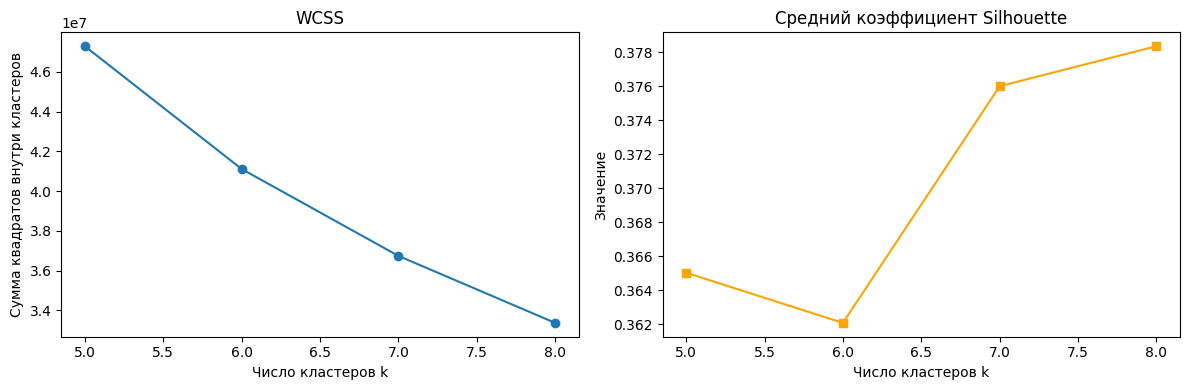

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_values, wcss, marker='o')
ax1.set_title('WCSS')
ax1.set_xlabel('Число кластеров k')
ax1.set_ylabel('Сумма квадратов внутри кластеров')

ax2.plot(k_values, silhouette_scores, marker='s', color='orange')
ax2.set_title('Средний коэффициент Silhouette')
ax2.set_xlabel('Число кластеров k')
ax2.set_ylabel('Значение')

plt.tight_layout()
plt.savefig('outputs/screenshots/kmeans_elbow_silhouette.png', dpi=150)
plt.show()

### 9. Выбор оптимального k и финальная кластеризация

In [14]:
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров по силуэту: {best_k}")

final_k = 8

print(f"Для финальной классификации используется k = {final_k}")

kmeans_final = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

labels_all = kmeans_final.fit_predict(X_scaled)


Оптимальное число кластеров по силуэту: 8
Для финальной классификации используется k = 8


### 10. Сохранение классифицированного растра

In [15]:
# Создание пустого массива меток исходного размера (rows*cols), заполнение NoData для невалидных пикселей
labels_full = np.full(pixels.shape[0], -1, dtype=np.int16)   # -1 = NoData
labels_full[valid_mask] = labels_all
labels_2d = labels_full.reshape(rows, cols).astype(np.int16)

# Обновление профиля для выходного растра (один слой, целочисленный)
out_profile = profile.copy()
out_profile.update({
    'count': 1,
    'dtype': 'int16',
    'nodata': -1,
    'compress': 'lzw'   # для уменьшения размера
})

output_path = "outputs/classified/landsat_kmeans_classified.tif"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
with rasterio.open(output_path, 'w', **out_profile) as dst:
    dst.write(labels_2d, 1)

print(f"Классифицированный растёр сохранён: {output_path}")

Классифицированный растёр сохранён: outputs/classified/landsat_kmeans_classified.tif


### 11. Визуализация карты кластеров

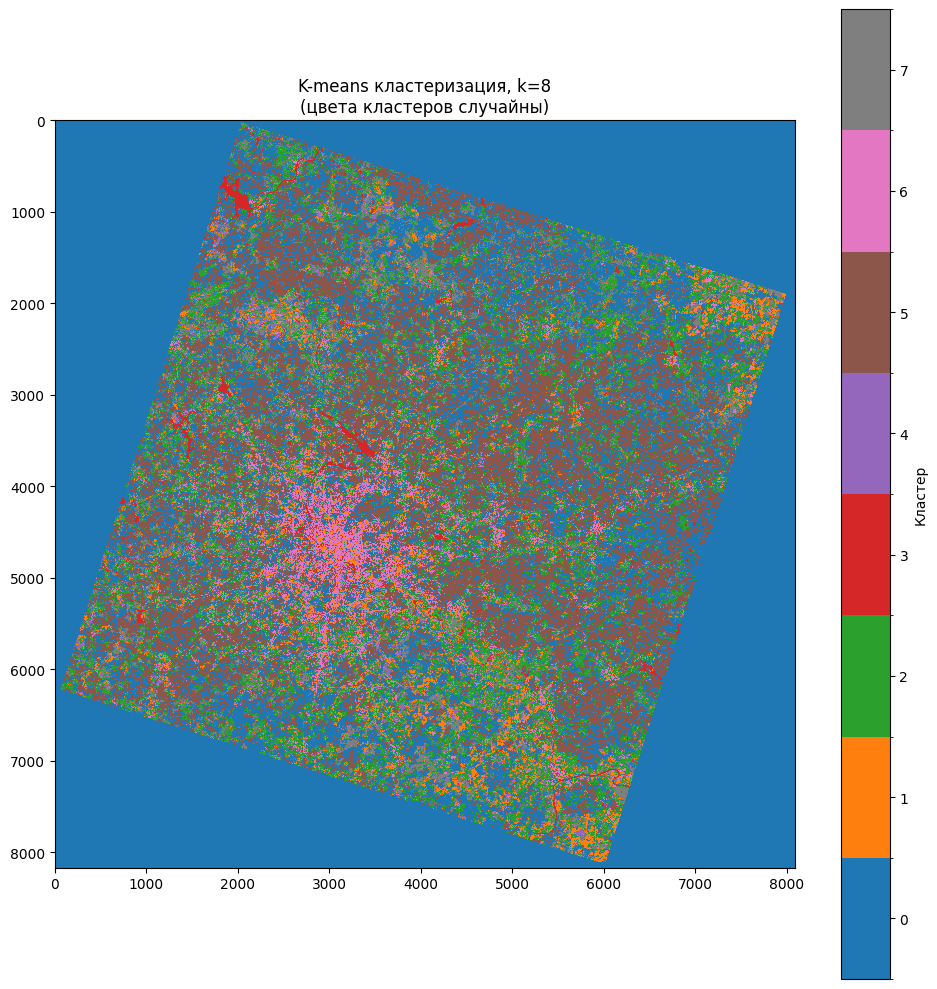

In [16]:
import matplotlib.colors as mcolors
cmap = plt.cm.tab10
norm = mcolors.BoundaryNorm(np.arange(-0.5, final_k+0.5, 1), final_k)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(labels_2d, cmap=cmap, norm=norm, interpolation='none')
cbar = plt.colorbar(im, ticks=np.arange(final_k), label='Кластер')
ax.set_title(f'K-means кластеризация, k={final_k}\n(цвета кластеров случайны)')
plt.tight_layout()
plt.savefig('outputs/screenshots/kmeans_classification_map.png', dpi=150, bbox_inches='tight')
plt.show()